# Routed lattice surgery on the diagonal syndrome-extraction schedule

Three joint measurements between two d×d surface-code patches, each routed through an ancilla corridor
that bends.  Every round runs the diagonal syndrome-extraction schedule of Kishony and Fowler
([arXiv:2602.09099](https://arxiv.org/abs/2602.09099)).

| | measurement | corridor | seams |
|---|---|---|---|
| Example 1 | Z̄₀Z̄₁ | U-shaped | two ordinary seams |
| Example 2 | Z̄₀X̄₁ | L-shaped | stretched seam at `q0`, ordinary seam at `q1` |
| Example 3 | Z̄₀X̄₁ | U-shaped | stretched seam at `q0`, ordinary seam at `q1` |

A seam is **stretched** when the two sides have checkerboards offset by half a cell: the seam has no
row of data qubits, and every check that crosses it has feet on both sides and none on the seam row.
Each stretched check is measured with three ancillas: a syndrome ancilla B, a flag ancilla A and a
relay S that sits on the seam (`DiagonalSurfaceCodeExtractionBlock` in
[`diagonal_se.py`](https://github.com/John-YuehanZhang/CircLS/blob/main/lightstim/qec_code/surface_code/rotated/diagonal_se.py)).
Neighbouring stretched checks alternate between two slot offsets (`'+'` and `'-'`).

For comparison, the diagonal schedule in tqec ([tqec#905](https://github.com/tqec/tqec/pull/905))
covers the regular plaquettes of the fixed-bulk convention; its stretched (extended) plaquettes keep
the default schedule, and spatial Hadamard pipes, which need them, are marked as an expected failure there.

The programs are compiled with `compile_ppm_sequence`
([`circls/pipeline.py`](https://github.com/John-YuehanZhang/CircLS/blob/main/circls/pipeline.py)), which enters
the compiler with a PPM sequence; the patch cells, orientations and corridor are fixed with the
`placement=`, `orientation=` and `router=` hooks
([`docs/API_HOOKS.md`](https://github.com/John-YuehanZhang/CircLS/blob/main/docs/API_HOOKS.md)).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pymatching
import stim
from IPython.display import SVG, display

from circls.interop.ir.gosc_gadgets import OutBit, PPMProgram, ProgramOp
from circls.pipeline import compile_ppm_sequence
from circls.tools.evaluate import inject_uniform_noise

## 0. Helpers

`joint_measurement(p0, p1)` is the program "measure P̄₀P̄₁, then read `q0` in P₀ and `q1` in P₁"; both
patches start in |0⟩.  `describe` prints the compiled circuit and its stretched checks, `show_merged_round`
draws the second merge round, `summarize_observables` lists the observables, and
`independent_observables` counts those that are independent modulo the detectors.

In [2]:
def joint_measurement(p0, p1):
    return PPMProgram(
        num_data=2,
        ops=[ProgramOp("mpp", {0: p0, 1: p1}),    # the joint measurement
             ProgramOp("mpp", {0: p0}),           # readout of q0
             ProgramOp("mpp", {1: p1})],          # readout of q1
        gadgets=[],
        out_bits=[OutBit(rec=k, flip=0) for k in range(3)],
    )

def stretched_checks(out):
    return [ch for ch in out.experiment._routes[0].layout.checks if ch.get("kf")]

def describe(out):
    exp, c = out.experiment, out.circuit
    print("corridor:", out.routes[0])
    print(f"merged-round schedule: {exp._sched[0]}, patch rotations: {exp.rotation_count}")
    print(f"{c.num_qubits} qubits, {c.num_ticks} ticks, {c.num_detectors} detectors, "
          f"{c.num_observables} observables")
    for ch in stretched_checks(out):
        kf = ch["kf"]
        print(f"  stretched check: syndrome B {ch['syn']}, flag A {kf['flag']}, relay S {kf['shared']}, "
              f"offset '{kf['orient']}', feet {ch['pauli']}")

def merge_rounds(out):
    # (start, end) ticks of the syndrome-extraction rounds that measure the corridor checks
    system, c = out.experiment.system, out.circuit
    ancillas = set()
    for ch in out.experiment._routes[0].layout.checks:
        ancillas.add(system.index_map[tuple(ch["syn"])])
        if ch.get("kf"):
            ancillas |= {system.index_map[tuple(ch["kf"]["flag"])], system.index_map[tuple(ch["kf"]["shared"])]}
    se_start, measured, tick = [], set(), 0
    for inst in c.flattened():
        if inst.name == "TICK":
            if inst.tag == "SE_start":
                se_start.append(tick)
            tick += 1
        elif stim.gate_data(inst.name).produces_measurements and any(
                t.value in ancillas for t in inst.targets_copy()):
            measured.add(tick)
    bounds = se_start + [tick + 1]
    return [(a, b) for a, b in zip(bounds, bounds[1:]) if any(a <= t < b for t in measured)]

def show_merged_round(out):
    rounds = merge_rounds(out)
    print("merge rounds (start, end tick):", rounds)
    display(SVG(str(out.circuit.diagram("detslice-svg", tick=rounds[1][0]))))
    display(SVG(str(out.circuit.diagram("detslice-with-ops-svg", tick=range(*rounds[1])))))

def summarize_observables(circuit):
    # for each observable: number of records and the ticks at which those records are measured
    tick, measured_at, obs = 0, [], {}
    for inst in circuit.flattened():
        if inst.name == "TICK":
            tick += 1
        elif inst.name == "OBSERVABLE_INCLUDE":
            k = int(inst.gate_args_copy()[0])
            obs.setdefault(k, set()).symmetric_difference_update(
                len(measured_at) + t.value for t in inst.targets_copy())
        elif inst.name not in ("DETECTOR", "QUBIT_COORDS", "SHIFT_COORDS") and stim.gate_data(inst.name).produces_measurements:
            measured_at += [tick] * len(inst.targets_copy())
    for k in sorted(obs):
        print(f"observable {k}: {len(obs[k]):2d} records, measured at ticks {sorted({measured_at[r] for r in obs[k]})}")

def gf2_rank(M):
    M, r = M.copy() % 2, 0
    for col in range(M.shape[1]):
        piv = np.nonzero(M[r:, col])[0]
        if len(piv) == 0:
            continue
        p = piv[0] + r
        M[[r, p]] = M[[p, r]]
        for i in np.nonzero(M[:, col])[0]:
            if i != r:
                M[i] ^= M[r]
        r += 1
        if r == M.shape[0]:
            break
    return r

def independent_observables(circuit):
    # GF(2) rank of (detectors + observables) minus the rank of the detectors
    n, m, dets, obs = circuit.num_measurements, 0, [], {}
    def vec(targets):
        v = np.zeros(n, dtype=np.uint8)
        for t in targets:
            v[m + t.value] ^= 1
        return v
    for inst in circuit.flattened():
        if inst.name == "DETECTOR":
            dets.append(vec(inst.targets_copy()))
        elif inst.name == "OBSERVABLE_INCLUDE":
            k = int(inst.gate_args_copy()[0])
            obs[k] = obs.get(k, np.zeros(n, dtype=np.uint8)) ^ vec(inst.targets_copy())
        elif inst.name not in ("TICK", "QUBIT_COORDS", "SHIFT_COORDS") and stim.gate_data(inst.name).produces_measurements:
            m += len(inst.targets_copy())
    D = np.array(dets)
    return gf2_rank(np.vstack([D] + list(obs.values()))) - gf2_rank(D)

## Example 1: Z̄₀Z̄₁ through a U-shaped corridor

* **Placement.**  Patch `q0` on coarse cell (0, 1) and `q1` on (2, 1), two cells apart.
* **Orientation.**  Both `X_vertical`: the corridor attaches on the north side of each patch, and a
  Z measurement through a north–south seam needs Z̄ to run along the seam.
* **Corridor.**  Cells (0, 0), (1, 0) and (2, 0), returned by the router hook.  Both seams are ordinary.

In [3]:
def compile_example1(d):
    return compile_ppm_sequence(joint_measurement("Z", "Z"), distance=d,
                                placement={"q0": (0, 1), "q1": (2, 1)},
                                orientation={"q0": "X_vertical", "q1": "X_vertical"},
                                router=lambda live_specs, step: [(0, 0), (1, 0), (2, 0)])

ex1 = compile_example1(3)
describe(ex1)
summarize_observables(ex1.circuit)
print("independent observables:", independent_observables(ex1.circuit))

corridor: [(0, 0), (1, 0), (2, 0)]
merged-round schedule: diagonal, patch rotations: 0
111 qubits, 41 ticks, 166 detectors, 6 observables
observable 0: 27 records, measured at ticks [17]
observable 1: 33 records, measured at ticks [39, 41]
observable 2:  3 records, measured at ticks [41]
observable 3: 27 records, measured at ticks [39]
observable 4:  3 records, measured at ticks [41]
observable 5: 30 records, measured at ticks [39, 41]
independent observables: 3


Three observables come from the syndrome tracker, which emits every parity that checks a logical
measurement outcome as an observable; three are the program bits, appended by `compile_ppm_sequence`.
`m` is the Z̄₀Z̄₁ outcome, read from the product of the corridor Z checks.

| index | records | what it checks |
|---|---|---|
| 0 | corridor Z checks, first merge round | `m` against the prepared value Z̄₀Z̄₁ = +1 |
| 1 | corridor Z checks, last merge round, and the Z̄₀ and Z̄₁ readouts | the closure `m` ⊕ Z̄₀ ⊕ Z̄₁ = 0 |
| 2 | Z̄₀ readout | Z̄₀ against the prepared value +1 |
| 3 | corridor Z checks, last merge round | program bit 0 (`m`) |
| 4 | Z̄₀ readout | program bit 1 (Z̄₀) |
| 5 | corridor Z checks, last merge round, and the Z̄₁ readout | program bit 2 (Z̄₁) |

Observables 2 and 4 are the same record set, and observable 0 equals observable 3 up to detectors, so
three of the six are independent.  The closure (index 1) checks logical outcomes against each other,
so it is an observable and not a detector.

The detector slice at the start of the second merge round shows the merged patch; below it, the same
merge round tick by tick (`detslice-with-ops-svg`).

merge rounds (start, end tick): [(7, 18), (18, 29), (29, 42)]


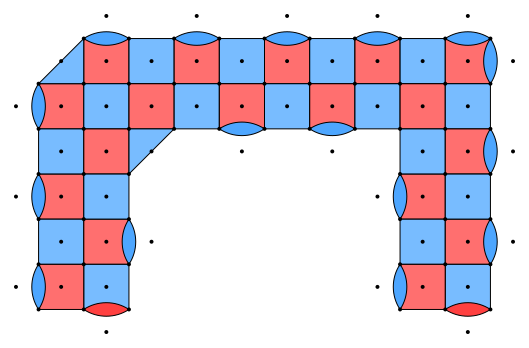

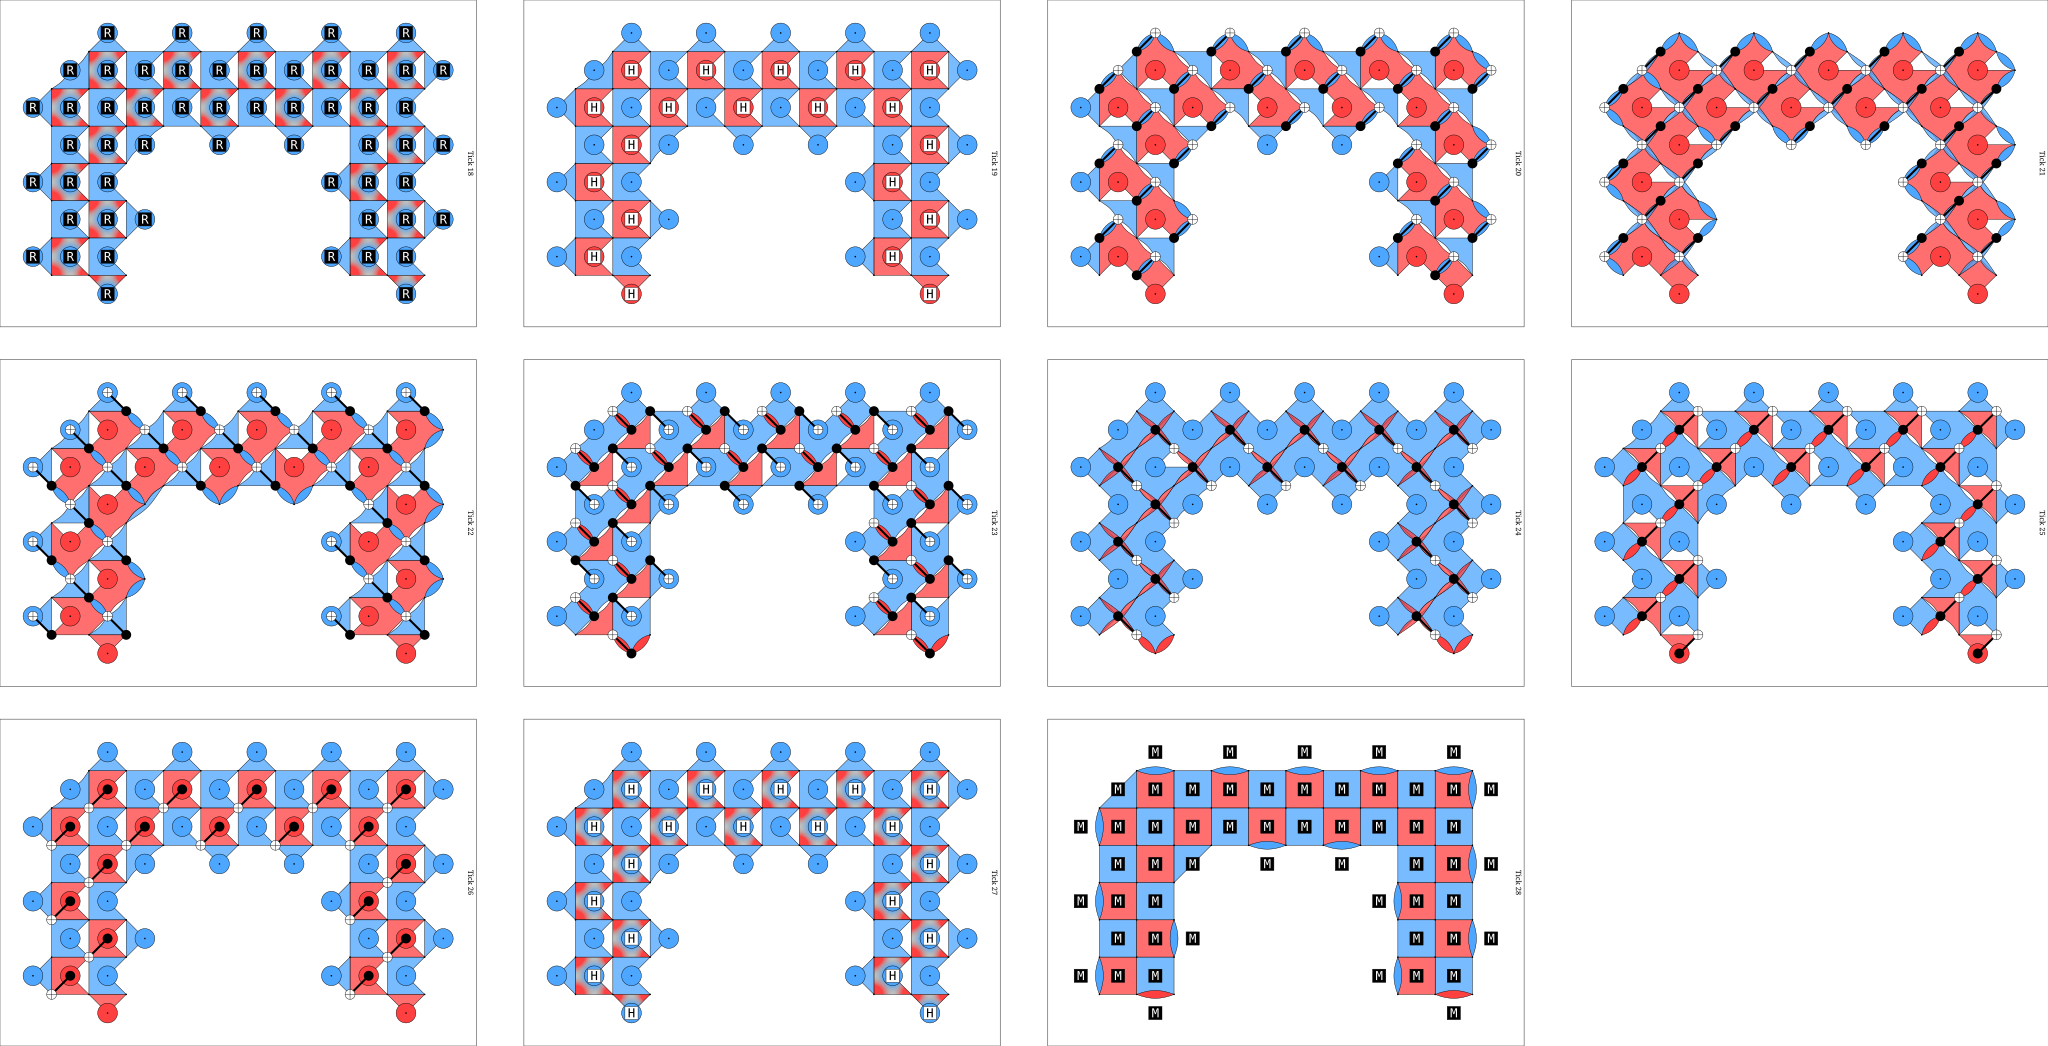

In [4]:
show_merged_round(ex1)

## Example 2: Z̄₀X̄₁ through an L-shaped corridor, stretched seam at `q0`

* **Placement.**  `q0` on coarse cell (0, 1) and `q1` on (2, 0).
* **Orientation.**  Both `X_vertical`.
* **Corridor.**  Cells (0, 0) and (1, 0): up from `q0`, then right to `q1`.  The corridor attaches to
  `q0` through a stretched seam and to `q1` through an ordinary seam.

With both patches in |0⟩, `m` and X̄₁ are random; the deterministic content is Z̄₀ and the closure
`m` ⊕ Z̄₀ ⊕ X̄₁, so the circuit has two independent observables.

In [5]:
def compile_example2(d):
    return compile_ppm_sequence(joint_measurement("Z", "X"), distance=d,
                                placement={"q0": (0, 1), "q1": (2, 0)},
                                orientation={"q0": "X_vertical", "q1": "X_vertical"},
                                router=lambda live_specs, step: [(0, 0), (1, 0)])

ex2 = compile_example2(3)
describe(ex2)
summarize_observables(ex2.circuit)
print("independent observables:", independent_observables(ex2.circuit))

corridor: [(0, 0), (1, 0)]
merged-round schedule: diagonal, patch rotations: 0
89 qubits, 41 ticks, 146 detectors, 4 observables
  stretched check: syndrome B (2, 8), flag A (2, 6), relay S (2, 7), offset '-', feet {(1, 5): 'Z', (3, 5): 'Z', (1, 9): 'X', (3, 9): 'X'}
  stretched check: syndrome B (4, 6), flag A (4, 8), relay S (4, 7), offset '+', feet {(3, 5): 'X', (5, 5): 'X', (3, 9): 'Z', (5, 9): 'Z'}
  stretched check: syndrome B (0, 6), flag A (0, 8), relay S (0, 7), offset '+', feet {(1, 5): 'X', (1, 9): 'Z'}
observable 0: 24 records, measured at ticks [39, 41]
observable 1:  3 records, measured at ticks [41]
observable 2:  3 records, measured at ticks [41]
observable 3: 21 records, measured at ticks [39, 41]
independent observables: 2


The corridor bends at cell (0, 0), and the d stretched checks (grey: Z feet on one side, X feet on the
other) cross the seam between `q0` and the corridor.  In the tick-by-tick round, each stretched check
runs its flag A, syndrome B and relay S gates inside the same window as the bulk checks.

merge rounds (start, end tick): [(7, 18), (18, 29), (29, 42)]


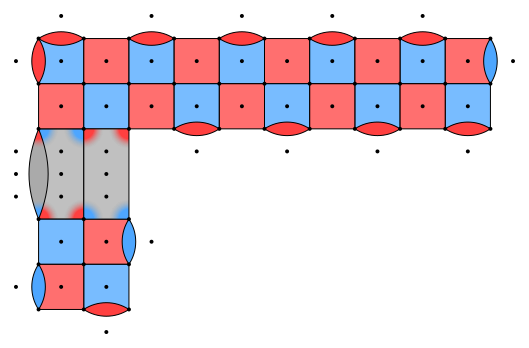

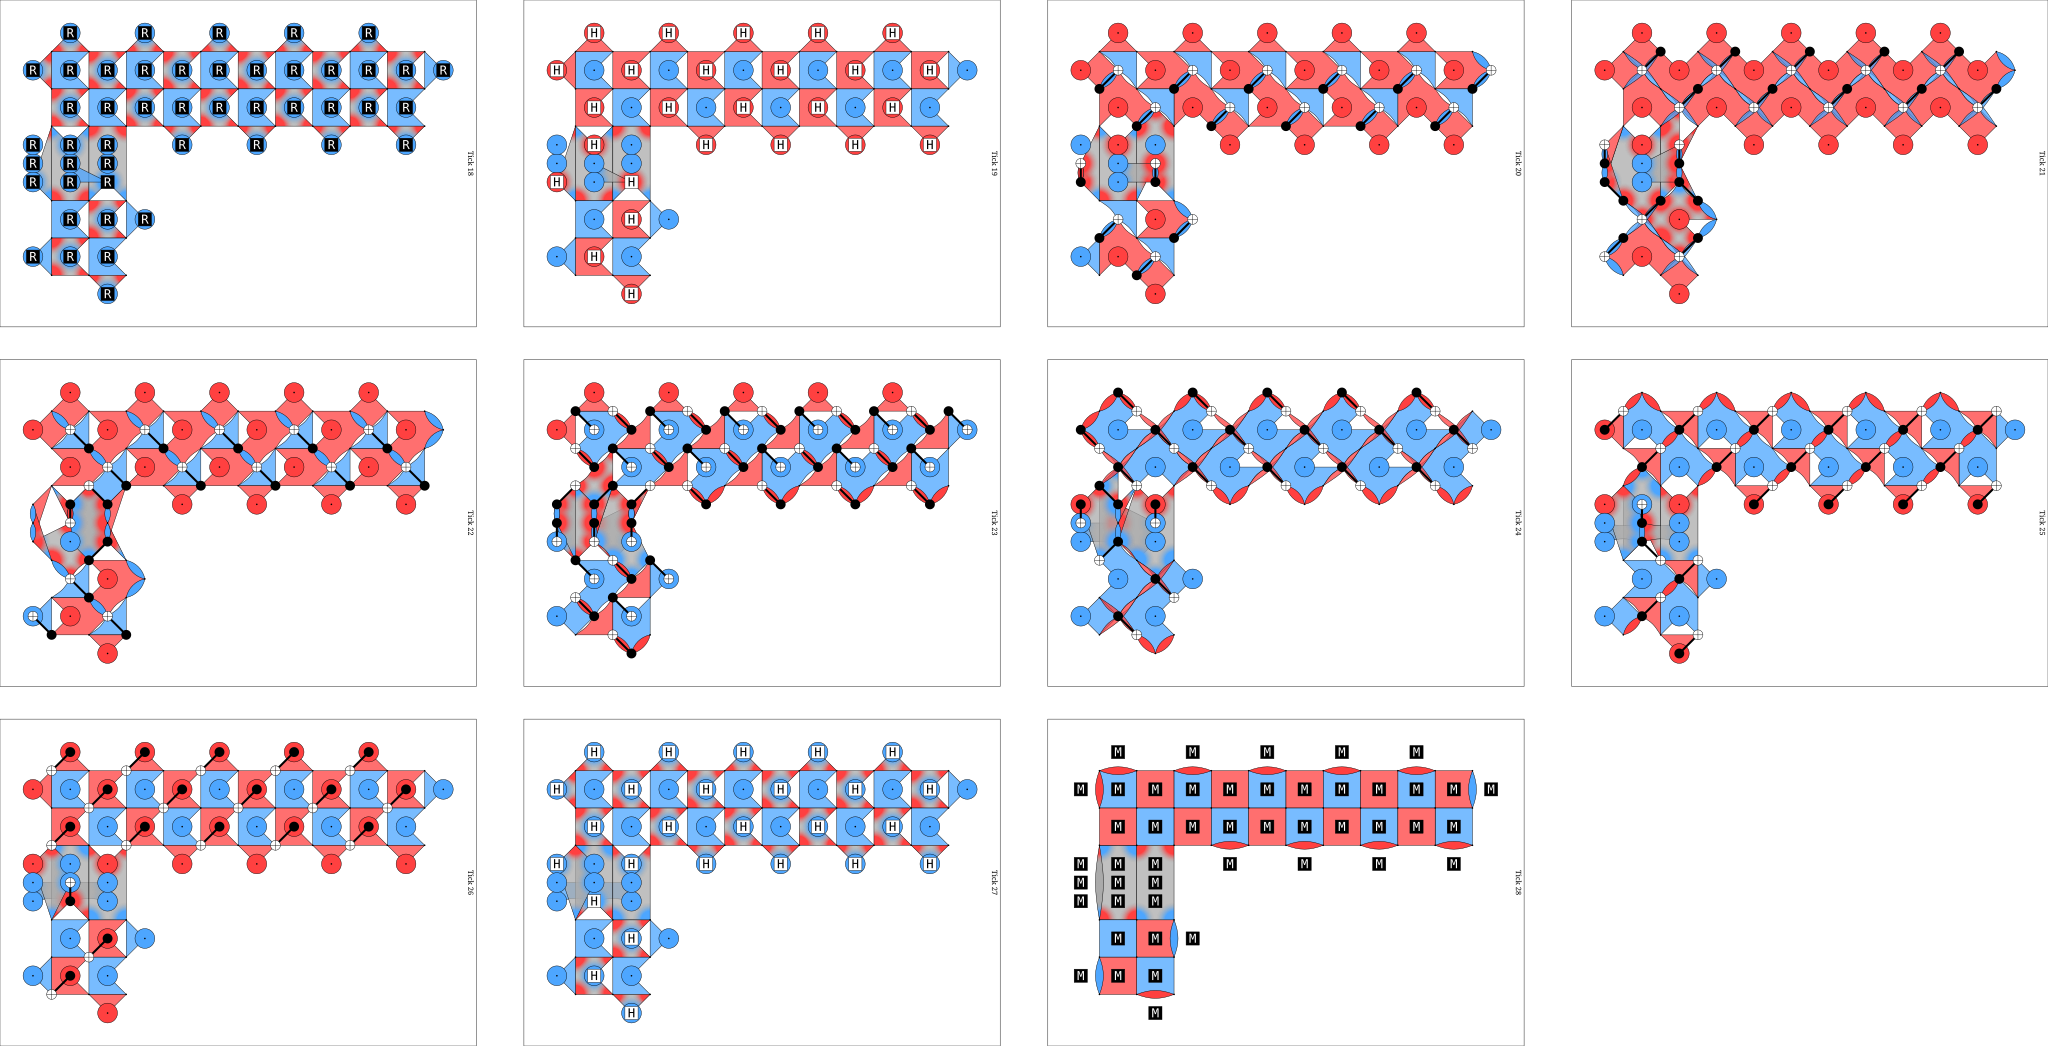

In [6]:
show_merged_round(ex2)

## Example 3: Z̄₀X̄₁ through a U-shaped corridor, stretched seam at `q0`

* **Placement.**  `q0` on coarse cell (0, 1) and `q1` on (2, 1), two cells apart.
* **Orientation.**  `q0` is `X_vertical` and `q1` is `X_horizontal`.
* **Corridor.**  Cells (0, 0), (1, 0) and (2, 0): up from `q0`, across, and down to `q1`.  The corridor
  attaches to `q0` through a stretched seam and to `q1` through an ordinary seam.

In [7]:
def compile_example3(d):
    return compile_ppm_sequence(joint_measurement("Z", "X"), distance=d,
                                placement={"q0": (0, 1), "q1": (2, 1)},
                                orientation={"q0": "X_vertical", "q1": "X_horizontal"},
                                router=lambda live_specs, step: [(0, 0), (1, 0), (2, 0)])

ex3 = compile_example3(3)
describe(ex3)
summarize_observables(ex3.circuit)
print("independent observables:", independent_observables(ex3.circuit))

corridor: [(0, 0), (1, 0), (2, 0)]
merged-round schedule: diagonal, patch rotations: 0
111 qubits, 42 ticks, 176 detectors, 4 observables
  stretched check: syndrome B (2, 8), flag A (2, 6), relay S (2, 7), offset '-', feet {(1, 5): 'Z', (3, 5): 'Z', (1, 9): 'X', (3, 9): 'X'}
  stretched check: syndrome B (4, 6), flag A (4, 8), relay S (4, 7), offset '+', feet {(3, 5): 'X', (5, 5): 'X', (3, 9): 'Z', (5, 9): 'Z'}
  stretched check: syndrome B (0, 6), flag A (0, 8), relay S (0, 7), offset '+', feet {(1, 5): 'X', (1, 9): 'Z'}
observable 0: 31 records, measured at ticks [40, 42]
observable 1:  3 records, measured at ticks [42]
observable 2:  3 records, measured at ticks [42]
observable 3: 28 records, measured at ticks [40, 42]
independent observables: 2


merge rounds (start, end tick): [(8, 19), (19, 30), (30, 43)]


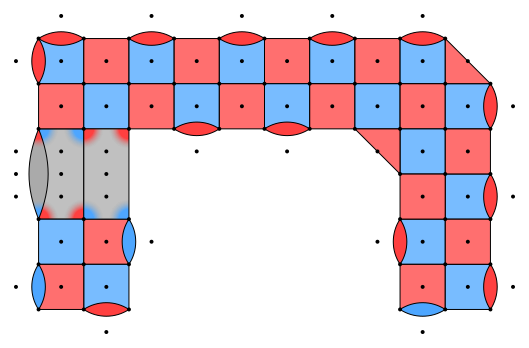

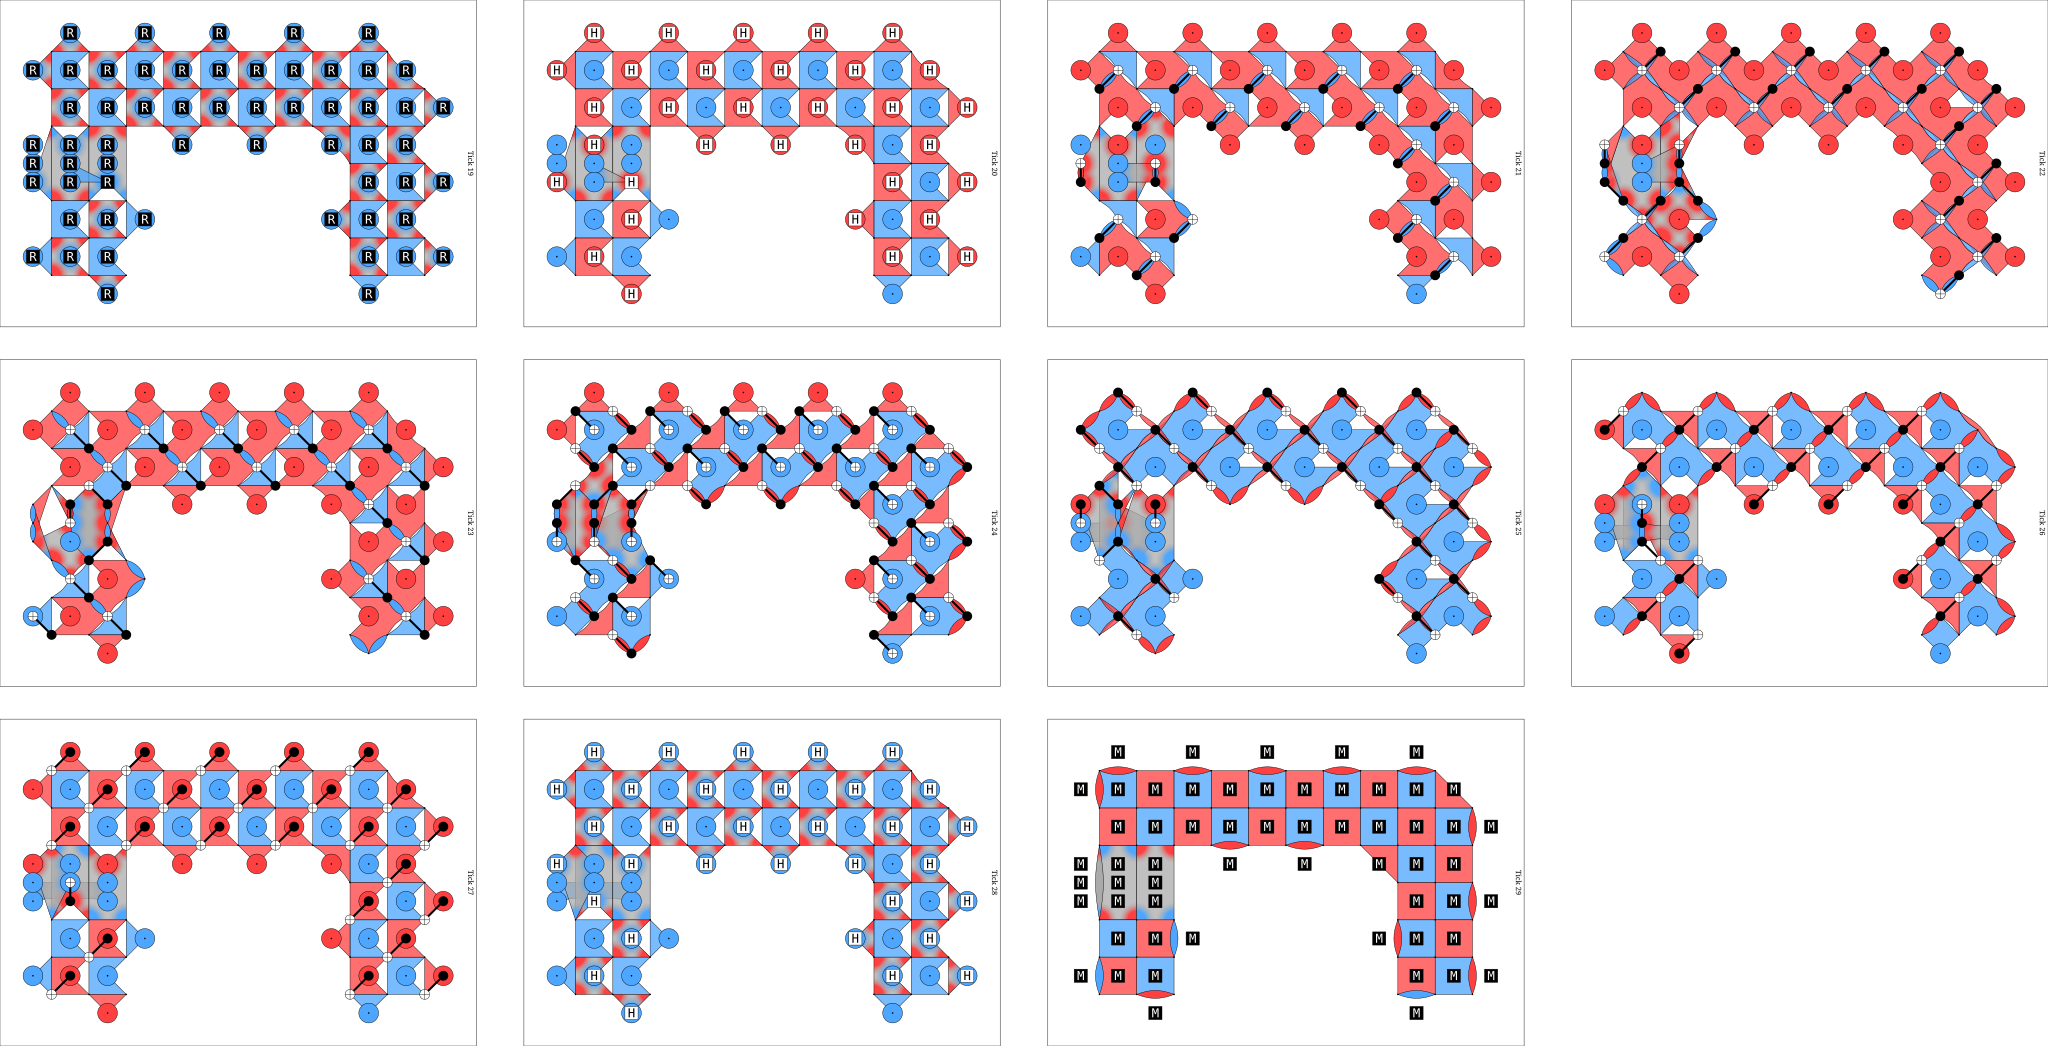

In [8]:
show_merged_round(ex3)

## Semantic check: each step measures only the product

With both patches in |0⟩, the program bits cannot tell a joint measurement from separate
measurements of its two factors.  `keeps_partner` checks this directly: it prepares and reads each patch
in the basis that commutes with the measured product (X̄₀X̄₁ for Example 1, X̄₀Z̄₁ for Examples 2 and 3;
initial data resets and final data readouts switched to those bases), and uses
`stim.Circuit.flow_generators` to list every deterministic measurement parity.  A measurement of the
product alone keeps the partner product deterministic and leaves its two factors random.

In [9]:
def keeps_partner(out, partner):
    # partner: basis per patch that commutes with the measured product, e.g. {"q0": "X", "q1": "Z"}
    system, c = out.experiment.system, out.circuit.flattened()
    logical = {(r["patch_name"], r["type"]): {tuple(system.qubit_coords[q]) for q in r["pauli"]}
               for r in system.logical_ops}
    coords = {q: tuple(v) for q, v in c.get_final_qubit_coordinates().items()}
    owner = {}
    for name in partner:                      # data qubits of each patch: its logicals' bounding box
        pts = logical[(name, "X")] | logical[(name, "Z")]
        xs, ys = [p[0] for p in pts], [p[1] for p in pts]
        for q, (x, y) in coords.items():
            if min(xs) <= x <= max(xs) and min(ys) <= y <= max(ys) and x % 2 == 1 and y % 2 == 1:
                owner[q] = name
    first_reset, last_meas = {}, {}
    for i, inst in enumerate(c):
        for t in inst.targets_copy():
            if t.is_qubit_target and t.value in owner:
                if inst.name in ("R", "RX") and t.value not in first_reset:
                    first_reset[t.value] = i
                if inst.name in ("M", "MX"):
                    last_meas[t.value] = i
    new = stim.Circuit()
    for i, inst in enumerate(c):
        if inst.name in ("DETECTOR", "OBSERVABLE_INCLUDE"):
            continue
        if inst.name in ("R", "RX", "M", "MX"):
            kind = inst.name[0]
            chosen = first_reset if kind == "R" else last_meas
            groups = {}
            for t in inst.targets_copy():
                if t.is_qubit_target and chosen.get(t.value) == i:
                    name = kind + ("X" if partner[owner[t.value]] == "X" else "")
                else:
                    name = inst.name
                groups.setdefault(name, []).append(t)
            for name, targets in groups.items():
                new.append(name, targets)
        else:
            new.append(inst)
    record, m = {}, 0
    for inst in new:
        if stim.gate_data(inst.name).produces_measurements:
            for t in inst.targets_copy():
                if t.value in owner:
                    record[coords[t.value]] = m   # ends at the final readout of each data qubit
                m += 1
    cols = sorted(record.values())
    flows = [f for f in new.flow_generators()
             if f.input_copy().weight == 0 and f.output_copy().weight == 0]
    span = np.zeros((len(flows), len(cols)), dtype=np.uint8)
    for r, f in enumerate(flows):
        for k in f.measurements_copy():
            if k in cols:
                span[r, cols.index(k)] ^= 1
    rank = gf2_rank
    def deterministic(points):
        v = np.zeros(len(cols), dtype=np.uint8)
        for p in points:
            v[cols.index(record[p])] = 1
        return rank(np.vstack([span, v])) == rank(span)
    a, b = logical[("q0", partner["q0"])], logical[("q1", partner["q1"])]
    return {f"{partner['q0']}0 {partner['q1']}1": deterministic(a ^ b),
            f"{partner['q0']}0 alone": deterministic(a), f"{partner['q1']}1 alone": deterministic(b)}

print("Example 1", keeps_partner(compile_example1(3), {"q0": "X", "q1": "X"}))
print("Example 2", keeps_partner(compile_example2(3), {"q0": "X", "q1": "Z"}))
print("Example 3", keeps_partner(compile_example3(3), {"q0": "X", "q1": "Z"}))

Example 1 {'X0 X1': True, 'X0 alone': False, 'X1 alone': False}
Example 2 {'X0 Z1': True, 'X0 alone': False, 'Z1 alone': False}


Example 3 {'X0 Z1': True, 'X0 alone': False, 'Z1 alone': False}


## Checks

At p = 0 no detector fires and every observable is deterministic.  Under the uniform circuit-level
depolarizing noise used throughout the CircLS paper (`inject_uniform_noise`), the shortest graphlike
logical error has length `d` for all three examples.

In [10]:
for name, compile_case in (("Example 1", compile_example1), ("Example 2", compile_example2), ("Example 3", compile_example3)):
    for d in (3, 5, 7):
        out = compile_case(d)
        circuit = out.circuit
        det, obs = circuit.compile_detector_sampler(seed=0).sample(256, separate_observables=True)
        noisy = inject_uniform_noise(circuit, 1e-3)
        print(f"{name} d={d}: schedule={out.experiment._sched[0]}, {circuit.num_qubits} qubits, "
              f"{circuit.num_detectors} detectors, {len(stretched_checks(out))} stretched checks, "
              f"p=0 silent={not det.any()}, deterministic={not obs.any()}, "
              f"graphlike distance={len(noisy.shortest_graphlike_error())}")

Example 1 d=3: schedule=diagonal, 111 qubits, 166 detectors, 0 stretched checks, p=0 silent=True, deterministic=True, graphlike distance=3


Example 1 d=5: schedule=diagonal, 287 qubits, 740 detectors, 0 stretched checks, p=0 silent=True, deterministic=True, graphlike distance=5


Example 1 d=7: schedule=diagonal, 543 qubits, 1962 detectors, 0 stretched checks, p=0 silent=True, deterministic=True, graphlike distance=7
Example 2 d=3: schedule=diagonal, 89 qubits, 146 detectors, 3 stretched checks, p=0 silent=True, deterministic=True, graphlike distance=3


Example 2 d=5: schedule=diagonal, 229 qubits, 626 detectors, 5 stretched checks, p=0 silent=True, deterministic=True, graphlike distance=5


Example 2 d=7: schedule=diagonal, 433 qubits, 1634 detectors, 7 stretched checks, p=0 silent=True, deterministic=True, graphlike distance=7


Example 3 d=3: schedule=diagonal, 111 qubits, 176 detectors, 3 stretched checks, p=0 silent=True, deterministic=True, graphlike distance=3


Example 3 d=5: schedule=diagonal, 287 qubits, 766 detectors, 5 stretched checks, p=0 silent=True, deterministic=True, graphlike distance=5


Example 3 d=7: schedule=diagonal, 543 qubits, 2012 detectors, 7 stretched checks, p=0 silent=True, deterministic=True, graphlike distance=7


## Logical error rate

Sample the noisy circuit and decode with PyMatching; a shot fails if any observable is wrong.

In [11]:
def logical_error_rate(circuit, shots, seed=0):
    # Sample the noisy circuit and decode with PyMatching; returns (errors, shots).
    dem = circuit.detector_error_model(decompose_errors=True)
    matcher = pymatching.Matching.from_detector_error_model(dem)
    det, obs = circuit.compile_detector_sampler(seed=seed).sample(shots, separate_observables=True)
    errors = int(np.any(matcher.decode_batch(det) != obs, axis=1).sum())
    return errors, shots

p = 2e-3
for name, compile_case in (("Example 1", compile_example1), ("Example 2", compile_example2), ("Example 3", compile_example3)):
    for d in (3, 5, 7):
        noisy = inject_uniform_noise(compile_case(d).circuit, p)
        errors, shots = logical_error_rate(noisy, shots=200_000)
        print(f"{name} p={p:g} d={d}: LER = {errors / shots:.2e} ({errors}/{shots})")

Example 1 p=0.002 d=3: LER = 9.71e-02 (19427/200000)


Example 1 p=0.002 d=5: LER = 3.84e-02 (7680/200000)


Example 1 p=0.002 d=7: LER = 1.56e-02 (3125/200000)


Example 2 p=0.002 d=3: LER = 6.96e-02 (13910/200000)


Example 2 p=0.002 d=5: LER = 2.84e-02 (5683/200000)


Example 2 p=0.002 d=7: LER = 1.13e-02 (2265/200000)


Example 3 p=0.002 d=3: LER = 8.61e-02 (17224/200000)


Example 3 p=0.002 d=5: LER = 3.48e-02 (6953/200000)


Example 3 p=0.002 d=7: LER = 1.38e-02 (2766/200000)
